# Lecture 4: Time Series Decomposition

*DASCI 270 - Time Series Analysis*

*Prepared by Sebastian C. Ibañez, PhD*

*Based on [FPPY Chapter 3](https://otexts.com/fpppy/nbs/03-decomposition.html)*

`And the Lord has sent to you all his servants, the prophets, again and again,
but you have not listened nor inclined your ear to hear.
(Jeremiah 25:4)`

Time series data can exhibit a variety of patterns. It is often helpful to split a time series into several components, each representing an underlying pattern category.

We have previously discussed three types of time series patterns: **trend**, **seasonality**, and **cycles**. In this notebook, we will explore some of the most common methods for extracting these components from a time series. This process, known as decomposition, is often performed to better understand the time series, but it can also be used to improve forecast accuracy.

In [1]:
%%capture
!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/PBS_unparsed.csv' -P ./data/
!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/global_economy.csv' -P ./data/
!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/aus_retail.csv' -P ./data/
!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/aus_production.csv' -P ./data/
!wget 'https://raw.githubusercontent.com/scibanez/msds2025ptb-tsa/refs/heads/main/data/us_employment.csv' -P ./data/

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

from prophet import Prophet

plt.style.use("ggplot")

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
})

pd.set_option("display.precision", 3)
np.set_printoptions(suppress=True)

## Time series components

We can think of a time series $y_t$ as comprising three components: a seasonal component $S_t$, a trend-cycle component $T_t$, and a remainder or residual component $R_t$. Note that the trend and cycle components are often combined into a single trend-cycle component.

There are two primary models for decomposition: additive and multiplicative.

### Additive Decomposition

If we assume an **additive model**, we can write the time series as:

\begin{align*}
    y_t &= S_t + T_t + R_t
\end{align*}

Here, the components are simply added together.

### Multiplicative Decomposition

If we assume a **multiplicative model**, we can write the time series as:

\begin{align*}
    y_t &= S_t \times T_t \times R_t
\end{align*}

Here, the components are multiplied together.

### Choosing a decomposition model

An additive decomposition is most appropriate when the magnitude of the seasonal fluctuations or the variation around the trend-cycle does not change with the level of the time series.

Conversely, a multiplicative decomposition is more appropriate when the variation in the seasonal pattern appears proportional to the level of the time series. This is a common phenomenon in economic time series.

A useful preliminary step is to transform the data to stabilize the variance over time, after which an additive decomposition can be used. The log transformation is a common choice. Applying a log transform to a multiplicative model results in an additive model:

\begin{align*}
    y_t &= S_t \times T_t \times R_t \quad \Longleftrightarrow \quad \log y_t = \log S_t + \log T_t + \log R_t
\end{align*}

This equivalence makes the log transformation a powerful tool for handling multiplicative relationships.

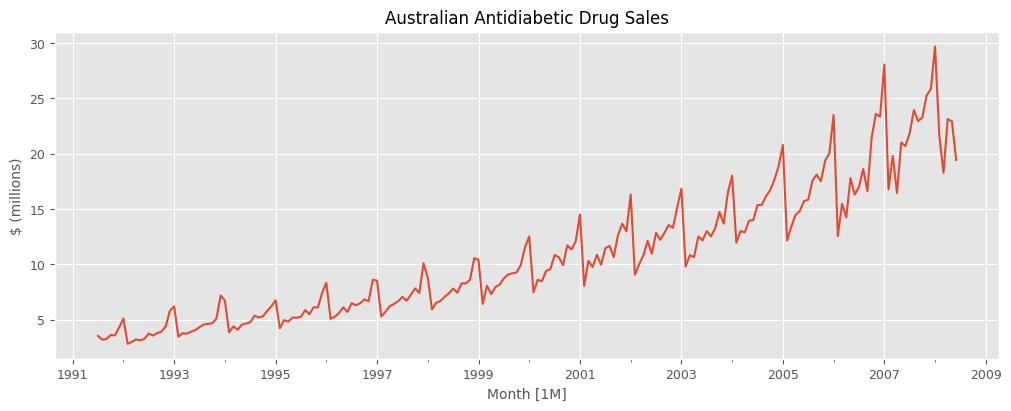

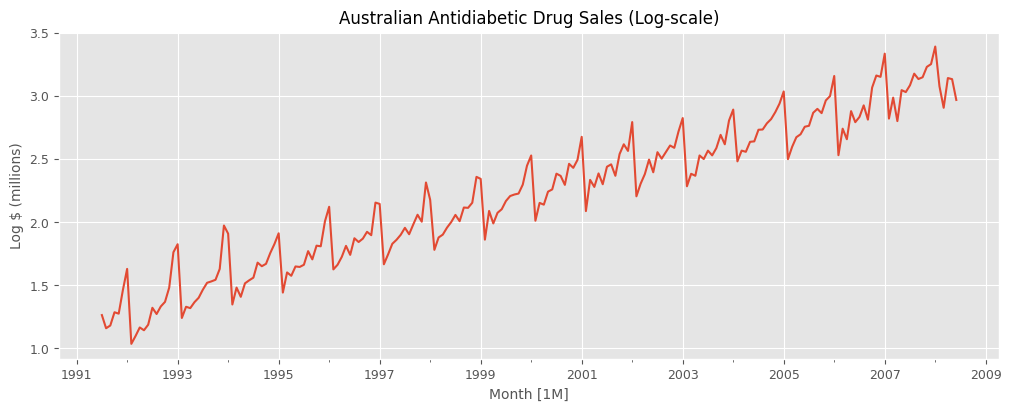

In [3]:
def plot_series(df, time_col, target_col, ylabel, xlabel, title):
  df = df.set_index(time_col)
  df[target_col].plot()
  plt.title(title)
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.autoscale()
  plt.show()

df = pd.read_csv('data/PBS_unparsed.csv', parse_dates=['Month'])
df = df[df['ATC2'] == 'A10']
df = df[['Month', 'Concession', 'Type', 'Cost']]
df_a10_total = df.groupby('Month', as_index=False).agg({'Cost': 'sum'})
df_a10_total.rename(columns={'Cost': 'TotalC'}, inplace=True)
df_a10_total['Cost'] = round(df_a10_total['TotalC']/1e6, 2)
df_a10_total['LogCost'] = np.log(df_a10_total['Cost'])

plot_series(df_a10_total,
            time_col='Month',
            target_col='Cost',
            xlabel='Month [1M]',
            ylabel='$ (millions)',
            title='Australian Antidiabetic Drug Sales')

plot_series(df_a10_total,
            time_col='Month',
            target_col='LogCost',
            xlabel='Month [1M]',
            ylabel='Log $ (millions)',
            title='Australian Antidiabetic Drug Sales (Log-scale)')

### Example: U.S. retail employment

Before diving into decomposition methods, let's look at an example. We will decompose the total number of persons (in thousands) employed monthly in the U.S. retail sector since 1990.

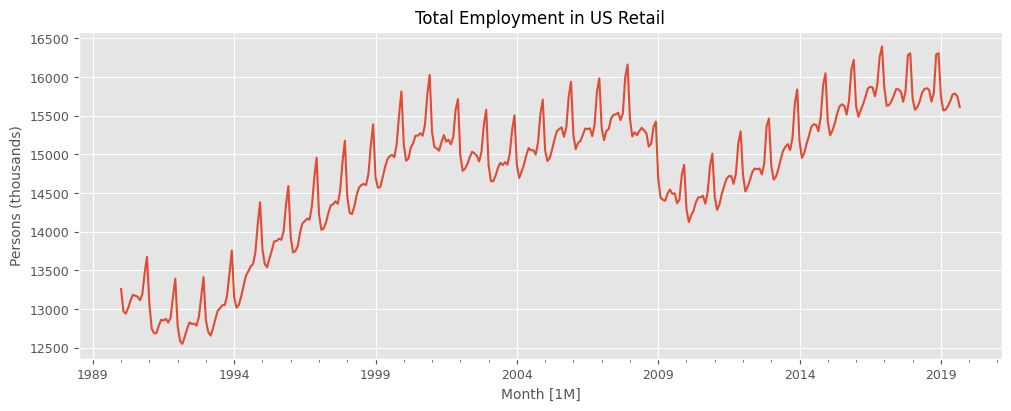

In [4]:
df_us_employment = pd.read_csv('data/us_employment.csv', parse_dates=['ds'])
df_us_employment = df_us_employment[(df_us_employment['unique_id'] == 'Retail Trade') & (df_us_employment['ds'] >= '1990-01-01')]

plot_series(df_us_employment,
            time_col='ds',
            target_col='y',
            xlabel='Month [1M]',
            ylabel='Persons (thousands)',
            title='Total Employment in US Retail')

The plot of the data reveals a clear increasing trend and a strong seasonal pattern. The magnitude of the seasonal swings appears to increase as the overall level of employment rises, suggesting a multiplicative model might be appropriate.

In [5]:
res = STL(df_us_employment['y'], period=12).fit()

df_dcmp = pd.DataFrame({
    'ds': df_us_employment["ds"],
    'data': df_us_employment["y"],
    'trend': res.trend,
    'seasonal': res.seasonal,
    "resid": res.resid
}).reset_index(drop=True)

df_dcmp.head()

,ds,data,trend,seasonal,resid
0,1990-01-01,13255.8,13296.249,-3.700,-36.749
1,1990-02-01,12966.3,13276.085,-288.398,-21.387
2,1990-03-01,12938.2,13255.663,-306.658,-10.805
3,1990-04-01,13012.3,13234.986,-235.775,13.089
4,1990-05-01,13108.3,13214.071,-115.399,9.628


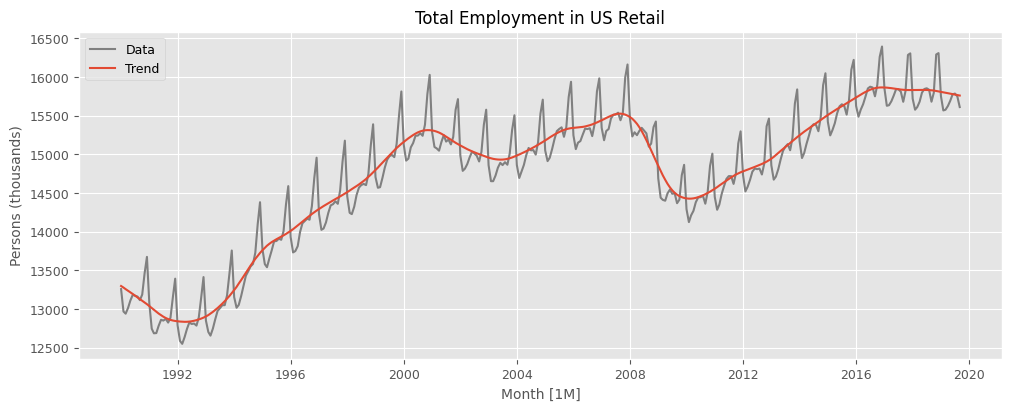

In [6]:
fig, ax = plt.subplots()
sns.lineplot(data=df_dcmp, x='ds', y='data', label='Data', color='gray')
sns.lineplot(data=df_dcmp, x='ds', y='trend', label='Trend') # Trend-Cycle
ax.set_title('Total Employment in US Retail')
ax.set_xlabel('Month [1M]')
ax.set_ylabel('Persons (thousands)')
plt.show()

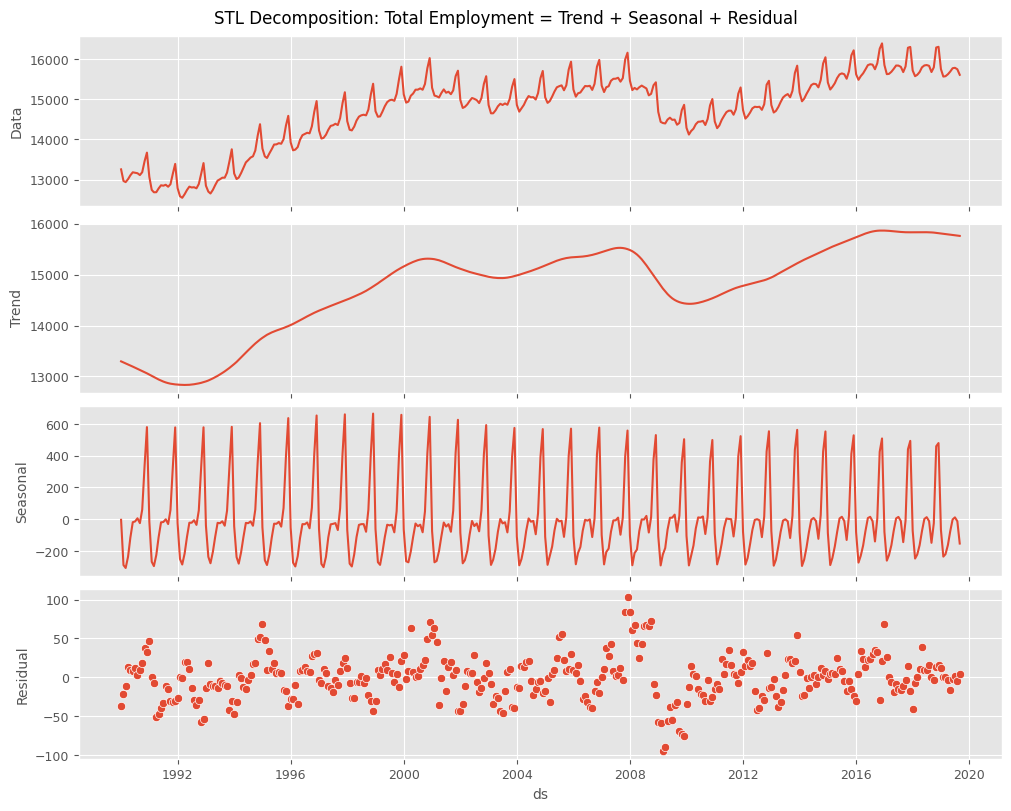

In [7]:
fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10, 8))
sns.lineplot(data=df_dcmp, x='ds', y='data', ax=axes[0])
sns.lineplot(data=df_dcmp, x='ds', y='trend', ax=axes[1])
sns.lineplot(data=df_dcmp, x='ds', y='seasonal', ax=axes[2])
sns.scatterplot(data=df_dcmp, x='ds', y='resid', ax=axes[3])
axes[0].set_ylabel('Data')
axes[1].set_ylabel('Trend')
axes[2].set_ylabel('Seasonal')
axes[3].set_ylabel('Residual')
fig.suptitle("STL Decomposition: Total Employment = Trend + Seasonal + Residual")
plt.show()

### Seasonally adjusted data

If we remove the seasonal component $S_t$ from the original series, the resulting series is called **seasonally adjusted**.

For additive decomposition, this is given by $y_t - S_t$, and for multiplicative decomposition, this is given by $y_t/S_t$.

Seasonally adjusted data can make it easier to see the underlying trend-cycle in the data.

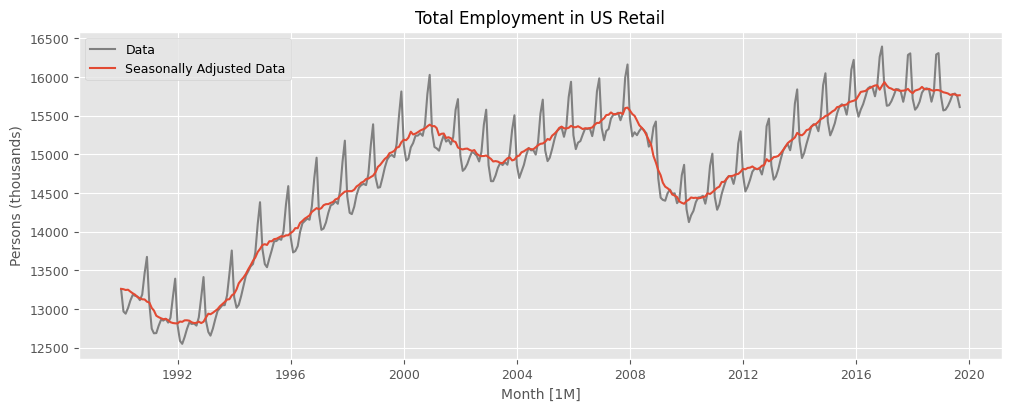

In [8]:
df_dcmp['season-adjust'] = df_dcmp['data'] - df_dcmp['seasonal']

fig, ax = plt.subplots()
sns.lineplot(data=df_dcmp, x='ds', y='data', label='Data', color='gray')
sns.lineplot(data=df_dcmp, x='ds', y='season-adjust', label='Seasonally Adjusted Data')
ax.set_title('Total Employment in US Retail')
ax.set_xlabel('Month [1M]')
ax.set_ylabel('Persons (thousands)')
plt.show()

## Moving averages

The classical method of time series decomposition, which originated in the 1920s, forms the basis of many modern techniques. The first step in classical decomposition is to estimate the trend-cycle using a moving average.

### Moving average smoothing

A **moving average (MA) of order** *m* is defined as:

\begin{align*}
    \hat{T}_t &= \frac{1}{m} \sum_{j=-k}^{k} y_{t+j}
\end{align*}

where $m = 2k + 1$. In other words, the estimate of the trend-cycle at time $t$ is obtained by averaging the time series values within $k$ periods of $t$. This is also known as a centered moving average or an $m-$MA.

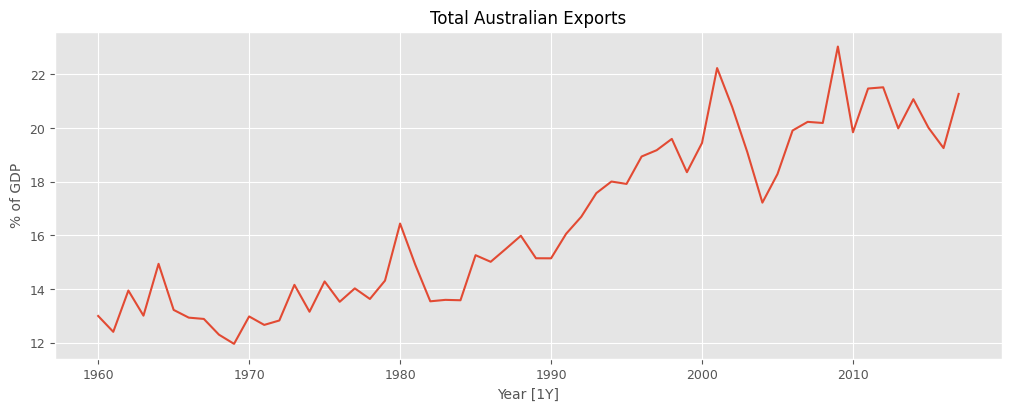

In [9]:
df_global_economy = pd.read_csv('data/global_economy.csv')
df_aus_exports = df_global_economy[df_global_economy['unique_id'] == 'Australia']
df_aus_exports = df_aus_exports[['unique_id', 'ds', 'Exports']]

plot_series(df_aus_exports,
            time_col='ds',
            target_col='Exports',
            xlabel='Year [1Y]',
            ylabel='% of GDP',
            title='Total Australian Exports')

In [10]:
df_aus_exports['5-MA'] = df_aus_exports['Exports'].rolling(window=5, center=True).mean()
df_aus_exports.head(10)

,unique_id,ds,Exports,5-MA
638,Australia,1960,12.994,NaN
639,Australia,1961,12.403,NaN
640,Australia,1962,13.943,13.457
641,Australia,1963,13.006,13.502
642,Australia,1964,14.938,13.608
643,Australia,1965,13.220,13.396
644,Australia,1966,12.932,13.254
645,Australia,1967,12.884,12.658
646,Australia,1968,12.298,12.609
647,Australia,1969,11.955,12.555


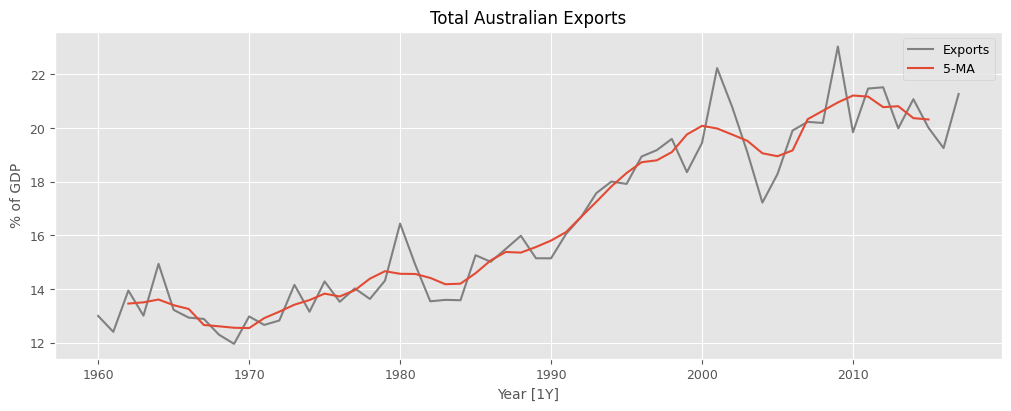

In [11]:
fig, ax = plt.subplots()
sns.lineplot(data=df_aus_exports, x='ds', y='Exports', label='Exports', color='gray')
sns.lineplot(data=df_aus_exports, x='ds', y='5-MA', label='5-MA')
ax.set_title('Total Australian Exports')
ax.set_xlabel('Year [1Y]')
ax.set_ylabel('% of GDP')
plt.show()

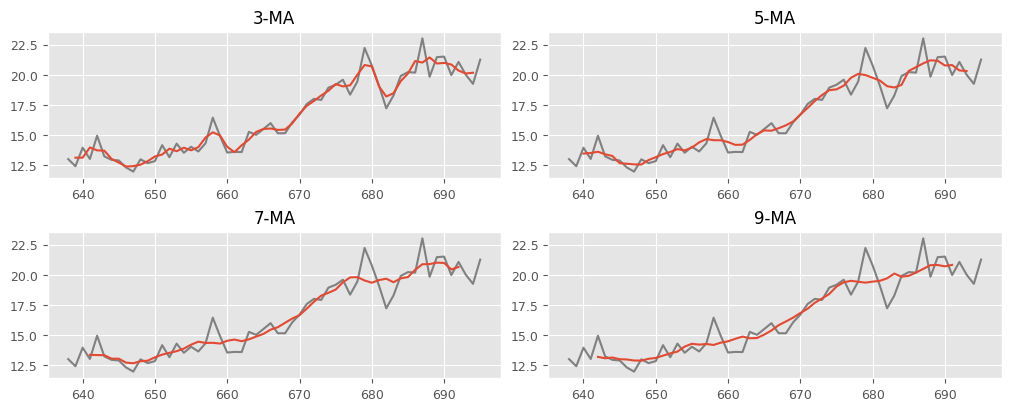

In [12]:
df_aus_exports["3-MA"] = df_aus_exports["Exports"].rolling(window=3, center=True).mean()
df_aus_exports["7-MA"] = df_aus_exports["Exports"].rolling(window=7, center=True).mean()
df_aus_exports["9-MA"] = df_aus_exports["Exports"].rolling(window=9, center=True).mean()

fig, ax = plt.subplots(nrows=2, ncols=2)
df_aus_exports["Exports"].plot(figsize=(10, 4), ax=ax[0, 0], color="grey")
df_aus_exports["Exports"].plot(figsize=(10, 4), ax=ax[0, 1], color="grey")
df_aus_exports["Exports"].plot(figsize=(10, 4), ax=ax[1, 0], color="grey")
df_aus_exports["Exports"].plot(figsize=(10, 4), ax=ax[1, 1], color="grey")
df_aus_exports['3-MA'].plot(figsize=(10, 4), ax=ax[0, 0])
df_aus_exports['5-MA'].plot(figsize=(10, 4), ax=ax[0, 1])
df_aus_exports['7-MA'].plot(figsize=(10, 4), ax=ax[1, 0])
df_aus_exports['9-MA'].plot(figsize=(10, 4), ax=ax[1, 1])
ax[0, 0].set_title('3-MA')
ax[0, 1].set_title('5-MA')
ax[1, 0].set_title('7-MA')
ax[1, 1].set_title('9-MA')
for _ in ax.flatten(): _.autoscale()
plt.show()

Some notes on the plots above:

- The trend-cycle estimate produced by a moving average is smoother than the original data, capturing the main movement of the series without the minor fluctuations.

- The order of the moving average, $m$, determines the smoothness of the trend-cycle estimate. A larger order results in a smoother curve.

- Simple moving averages are typically of an odd order (e.g., 3, 5, 7) to ensure they are symmetric.

### Moving averages of moving averages

It is also possible to apply a moving average to an already smoothed series. A primary reason for doing this is to make an even-order moving average symmetric.

In [13]:
df_aus_production = pd.read_csv("data/aus_production.csv", parse_dates=["ds"])
df_aus_production = df_aus_production[df_aus_production["ds"] >= "1992-01-01"]
df_beer = df_aus_production[["ds", "Beer"]].reset_index(drop=True)
df_beer.insert(0, "unique_id", "beer")
df_beer.rename(columns={"Beer": "y"}, inplace=True)
df_beer["4-MA"] = df_beer["y"].rolling(window=4, center=True).mean() # look 2 behind, 1 infront
df_beer["2x4-MA"] = df_beer["4-MA"].rolling(window=2, center=True).mean()
df_beer

,unique_id,ds,y,4-MA,2x4-MA
0,beer,1992-01-01,443,NaN,NaN
1,beer,1992-04-01,410,NaN,NaN
2,beer,1992-07-01,420,451.25,NaN
3,beer,1992-10-01,532,448.75,450.000
4,beer,1993-01-01,433,451.50,450.125
...,...,...,...,...,...
69,beer,2009-04-01,398,430.00,428.875
70,beer,2009-07-01,419,430.00,430.000
71,beer,2009-10-01,488,429.75,429.875
72,beer,2010-01-01,414,423.75,426.750


The notation `2x4-MA` in the last column means a 4-MA followed by a 2-MA.

When a 2-MA follows a moving average of an even order (such as 4), it is called a **centred moving average of order 4**. This is because the results are now symmetric. To see that this is the case, we can write the 2x4-MA as follows:

\begin{align*}
    \hat{T}_t &= \frac{1}{2}\left[ \frac{1}{4}(y_{t-2} + y_{t-1} + y_{t} + y_{t+1}) + \frac{1}{4}(y_{t-1} + y_{t} + y_{t+1} + y_{t+2}) \right] \\
    &= \frac{1}{8}y_{t-2} + \frac{1}{4}y_{t-1} + \frac{1}{4}y_{t} + \frac{1}{4}y_{t+1} + \frac{1}{8}y_{t+2}
\end{align*}

It is now a weighted average of observations that is symmetric.

Other combinations of moving averages are also possible. For example, a 3x3-MA is often used, and consists of a moving average of order 3 followed by another moving average of order 3. In general, an even order MA should be followed by an even order MA to make it symmetric. Similarly, an odd order MA should be followed by an odd order MA.

### Estimating the trend-cycle with seasonal data

Centered moving averages are commonly used to estimate the trend-cycle from seasonal data. The order of the MA is chosen to match the seasonal period, which effectively averages out the seasonal variation.

If the seasonal period, $m$, is an **even** number, we use a **2xm-MA** to estimate the trend-cycle. For example, a 2x12-MA can be used for monthly data.

If the seasonal period, $m$, is an **odd** number, we use an **m-MA** to estimate the trend-cycle. For example, a 7-MA can be used for daily data with a weekly seasonality.

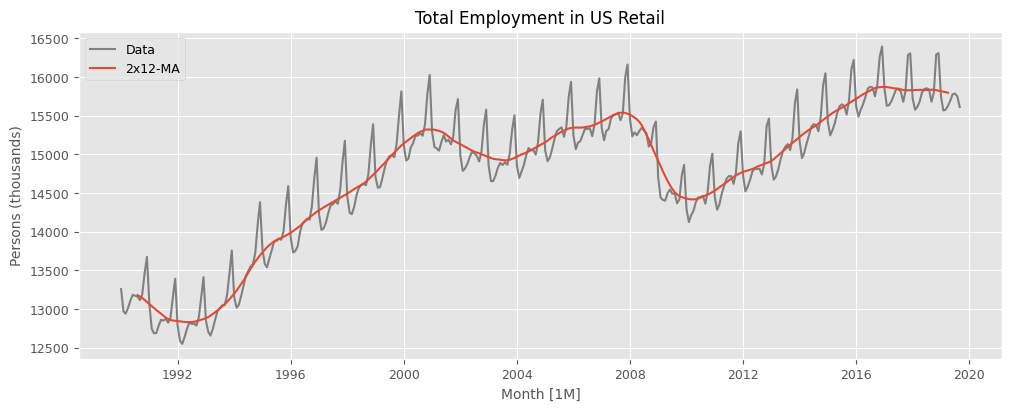

In [14]:
df_us_employment_ma = df_us_employment.copy()
df_us_employment_ma["12-MA"] = df_us_employment_ma["y"].rolling(window=12, center=True).mean()
df_us_employment_ma["2x12-MA"] = df_us_employment_ma["12-MA"].rolling(window=2, center=True).mean()

fig, ax = plt.subplots()
sns.lineplot(data=df_us_employment_ma, x='ds', y='y', label='Data', color='gray')
sns.lineplot(data=df_us_employment_ma, x='ds', y='2x12-MA', label='2x12-MA')
ax.set_title('Total Employment in US Retail')
ax.set_xlabel('Month [1M]')
ax.set_ylabel('Persons (thousands)')
plt.show()

## Classical decomposition

This method, developed in the 1920s, is a straightforward approach that assumes the seasonal component is constant from year to year.

In the notation below, $m$ refers to the seasonal period (e.g. $m=4$ for quarterly data, $m=12$ for monthly data, $m=7$ for daily data with weekly pattern).

### Additive Decomposition

Steps:

1. If $m$ is an even number, compute $\hat{T}_t$ using a $2 \times m$-MA. Else, compute $\hat{T}_t$ using an $m$-MA.
2. Calculate the detrended series $y_t - \hat{T}_t$.
3. To estimate $\hat{S}_t$, average the detrended values for that season, then concatenate and replicate the sequence for the length of the series.
4. The remainder is then given by $\hat{R}_t = y_t - \hat{T}_t - \hat{S}_t$.

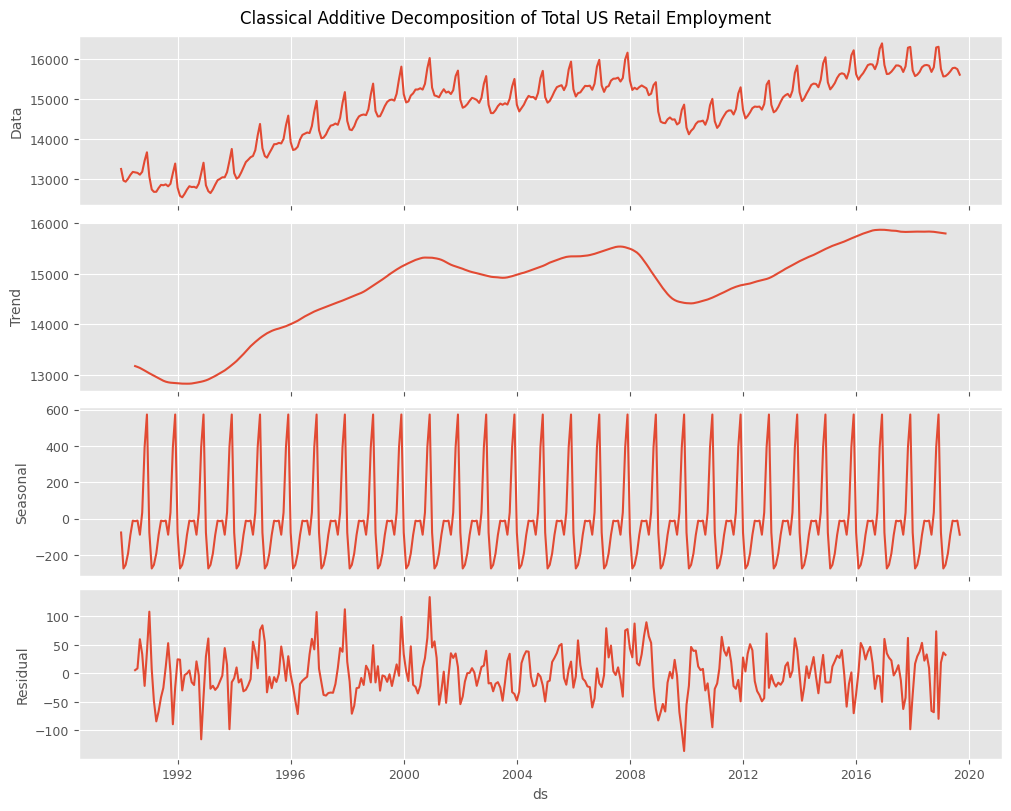

In [15]:
res = seasonal_decompose(df_us_employment.set_index("ds")['y'], model='additive')

df_dcmp = pd.DataFrame({
    'ds': df_us_employment["ds"],
    'data': df_us_employment["y"],
    'trend': res.trend.values,
    'seasonal': res.seasonal.values,
    "resid": res.resid.values
}).reset_index(drop=True)

fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10, 8))
sns.lineplot(data=df_dcmp, x='ds', y='data', ax=axes[0])
sns.lineplot(data=df_dcmp, x='ds', y='trend', ax=axes[1])
sns.lineplot(data=df_dcmp, x='ds', y='seasonal', ax=axes[2])
sns.lineplot(data=df_dcmp, x='ds', y='resid', ax=axes[3]) # can swap to scatter plot if you want
#sns.scatterplot(data=df_dcmp, x='ds', y='resid', ax=axes[3])
axes[0].set_ylabel('Data')
axes[1].set_ylabel('Trend')
axes[2].set_ylabel('Seasonal')
axes[3].set_ylabel('Residual')
fig.suptitle("Classical Additive Decomposition of Total US Retail Employment")
plt.show()

### Multiplicative Decomposition

Steps:

1. If $m$ is an even number, compute $\hat{T}_t$ using a $2 \times m$-MA. Else, compute $\hat{T}_t$ using an $m$-MA.
2. Calculate the detrended series $y_t/\hat{T}_t$.
3. To estimate $\hat{S}_t$, average the detrended values for that season, then concatenate and replicate the sequence for the length of the series.
4. The remainder is then given by $\hat{R}_t = y_t/(\hat{T}_t \hat{S}_t)$.

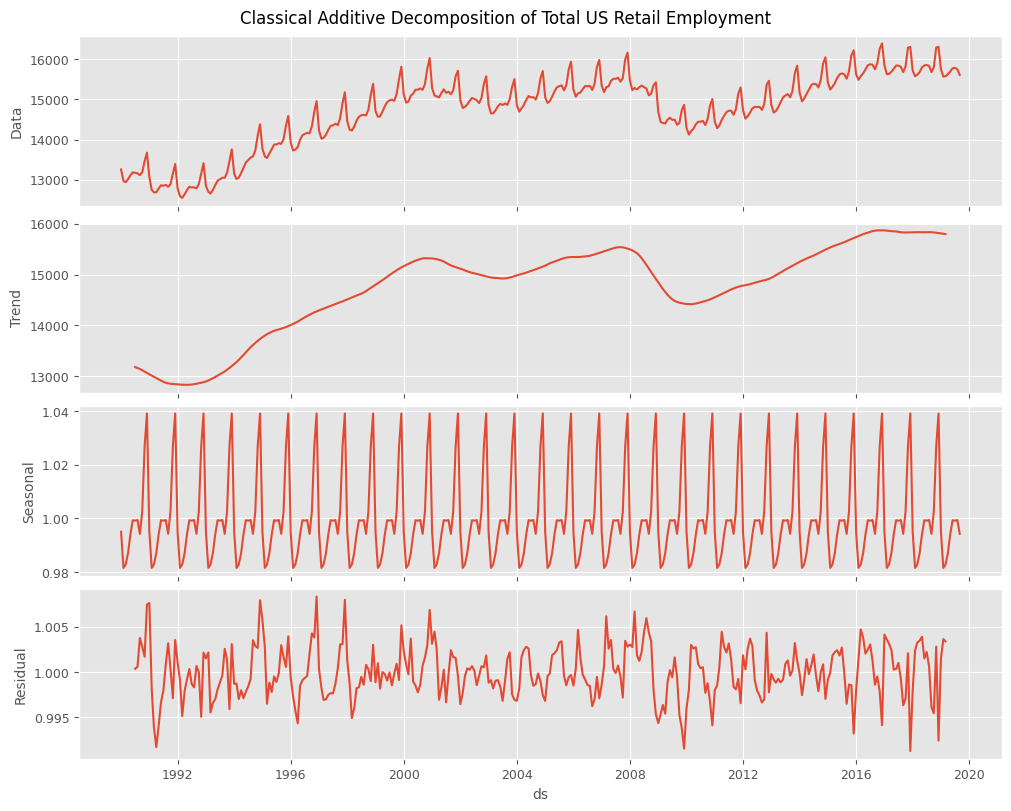

In [16]:
res = seasonal_decompose(df_us_employment.set_index("ds")['y'], model='multiplicative')

df_dcmp = pd.DataFrame({
    'ds': df_us_employment["ds"],
    'data': df_us_employment["y"],
    'trend': res.trend.values,
    'seasonal': res.seasonal.values,
    "resid": res.resid.values
}).reset_index(drop=True)

fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10, 8))
sns.lineplot(data=df_dcmp, x='ds', y='data', ax=axes[0])
sns.lineplot(data=df_dcmp, x='ds', y='trend', ax=axes[1])
sns.lineplot(data=df_dcmp, x='ds', y='seasonal', ax=axes[2])
sns.lineplot(data=df_dcmp, x='ds', y='resid', ax=axes[3]) # can swap to scatter plot if you want
#sns.scatterplot(data=df_dcmp, x='ds', y='resid', ax=axes[3])
axes[0].set_ylabel('Data')
axes[1].set_ylabel('Trend')
axes[2].set_ylabel('Seasonal')
axes[3].set_ylabel('Residual')
fig.suptitle("Classical Additive Decomposition of Total US Retail Employment")
plt.show()

### Notes on Classical Decomposition

While classical decomposition is still widely used, it is not recommended, as there are now several much better methods. Some of the problems with classical decomposition include:

- The trend-cycle estimate is unavailable for the first and last few observations.

- The trend-cycle estimate tends to over-smooth rapid changes in the data.

- It assumes the seasonal component is constant from year to year, which is often not the case for longer time series (e.g., electricity demand patterns changing over decades).

- The method is not robust to outliers. Unusual values (e.g., from an industrial dispute or a natural disaster) can distort the estimates of the components.

## STL decomposition

**STL (Seasonal and Trend Decomposition using LOESS)** is a versatile and robust method for decomposing time series, developed by R. B. Cleveland et al. (1990). **LOESS (locally estimated scatterplot smoothing)** is a method for estimating nonlinear relationships.

STL has several advantages over classical decomposition:

- It allows the seasonal component to change over time, and the user can control the rate of change.
- The smoothness of the trend-cycle can also be controlled by the user.
- It can be made robust to outliers. Unusual observations will not affect the trend-cycle and seasonal components but will instead be isolated in the remainder component.

The main disadvantages of STL are that it only supports additive decompositions and does not automatically handle calendar variations (like trading days or holidays). However, a multiplicative decomposition can be achieved by first taking the log of the data and then back-transforming the components.

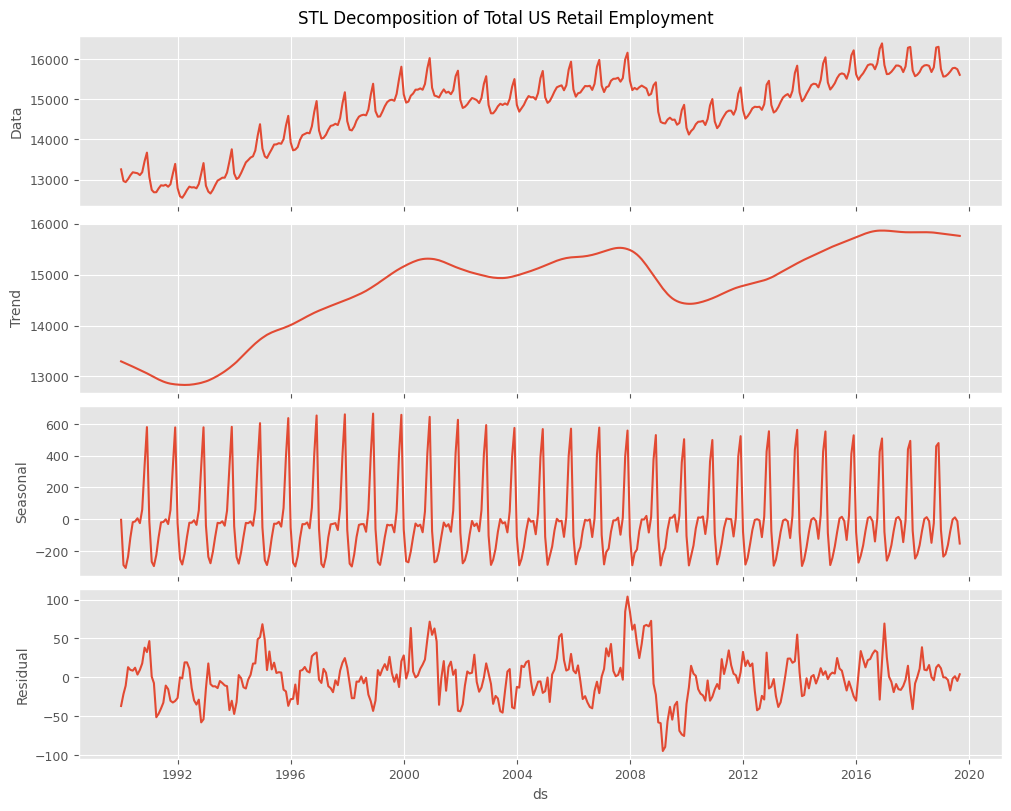

In [17]:
res = STL(df_us_employment['y'], period=12).fit()

df_dcmp = pd.DataFrame({
    'ds': df_us_employment["ds"],
    'data': df_us_employment["y"],
    'trend': res.trend,
    'seasonal': res.seasonal,
    "resid": res.resid
}).reset_index(drop=True)

fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10, 8))
sns.lineplot(data=df_dcmp, x='ds', y='data', ax=axes[0])
sns.lineplot(data=df_dcmp, x='ds', y='trend', ax=axes[1])
sns.lineplot(data=df_dcmp, x='ds', y='seasonal', ax=axes[2])
sns.lineplot(data=df_dcmp, x='ds', y='resid', ax=axes[3]) # can swap to scatter plot if you want
#sns.scatterplot(data=df_dcmp, x='ds', y='resid', ax=axes[3])
axes[0].set_ylabel('Data')
axes[1].set_ylabel('Trend')
axes[2].set_ylabel('Seasonal')
axes[3].set_ylabel('Residual')
fig.suptitle("STL Decomposition of Total US Retail Employment")
plt.show()

### Notes on STL

- It is possible to obtain a multiplicative decomposition by first taking logs of the data, then back-transforming the components.
- The `seasonal` and `trend` parameters control how rapidly the trend-cycle and seasonal components can change. Smaller values allow for more rapid changes.

See the statsmodels [API](https://www.statsmodels.org/stable/examples/notebooks/generated/stl_decomposition.html) for a more detailed tutorial.

## Prophet model

A more recent proposal for an additive time series model is [Prophet](https://facebook.github.io/prophet/), introduced by Facebook ([S. J. Taylor & Letham, 2018](https://doi.org/10.1080/00031305.2017.1380080)). It works best with time series that have strong seasonality and several seasons of historical data.

Prophet can be viewed as a nonlinear regression model of the form:

\begin{align*}
    y_t &= g(t) + s(t) + h(t) + \varepsilon_t
\end{align*}

where:
- $g(t)$ is the trend function, which models non-periodic changes. By default, it is a piecewise-linear "growth term."
- $s(t)$ describes the seasonal patterns (e.g., yearly, weekly)
- $h(t)$ represents the effects of holidays or other irregular events.
- $\varepsilon_t$ is the error term, assumed to be white noise.

Some notes on the Prophet model:

- The knots (or changepoints) for the piecewise-linear trend are automatically selected, though they can also be specified manually.
- The seasonal components are modeled using Fourier series.
- Holiday effects are added as simple dummy variables.
- The model is estimated using a Bayesian approach to allow for automatic selection of the changepoints and other model characteristics.

In [18]:
df_p = df_us_employment.drop(['unique_id'], axis=1).reset_index(drop=True)

model = Prophet()
model.fit(df_p)

fitted = model.predict()
fitted.index = df_p.ds

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpkozy55xb/_igo_kgq.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpkozy55xb/bztjlj0r.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=69230', 'data', 'file=/tmp/tmpkozy55xb/_igo_kgq.json', 'init=/tmp/tmpkozy55xb/bztjlj0r.json', 'output', 'file=/tmp/tmpkozy55xb/prophet_model5ezfqwil/prophet_model-20250702211414.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
21:14:14 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
21:14:14 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [19]:
fitted

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
ds,,,,,,,,,,,,,,,,
1990-01-01,1990-01-01,13277.776,13096.673,13305.915,13277.776,13277.776,-78.197,-78.197,-78.197,-78.197,-78.197,-78.197,0.0,0.0,0.0,13199.579
1990-02-01,1990-02-01,13257.617,12882.681,13077.044,13257.617,13257.617,-280.061,-280.061,-280.061,-280.061,-280.061,-280.061,0.0,0.0,0.0,12977.556
1990-03-01,1990-03-01,13239.408,12885.002,13078.919,13239.408,13239.408,-261.851,-261.851,-261.851,-261.851,-261.851,-261.851,0.0,0.0,0.0,12977.558
1990-04-01,1990-04-01,13219.249,12920.488,13119.190,13219.249,13219.249,-195.944,-195.944,-195.944,-195.944,-195.944,-195.944,0.0,0.0,0.0,13023.305
1990-05-01,1990-05-01,13199.740,12996.784,13209.516,13199.740,13199.740,-95.635,-95.635,-95.635,-95.635,-95.635,-95.635,0.0,0.0,0.0,13104.105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-05-01,2019-05-01,15980.739,15786.849,15976.804,15980.739,15980.739,-94.794,-94.794,-94.794,-94.794,-94.794,-94.794,0.0,0.0,0.0,15885.945
2019-06-01,2019-06-01,15990.627,15877.071,16072.002,15990.627,15990.627,-16.727,-16.727,-16.727,-16.727,-16.727,-16.727,0.0,0.0,0.0,15973.900
2019-07-01,2019-07-01,16000.195,15894.765,16089.864,16000.195,16000.195,-14.503,-14.503,-14.503,-14.503,-14.503,-14.503,0.0,0.0,0.0,15985.692


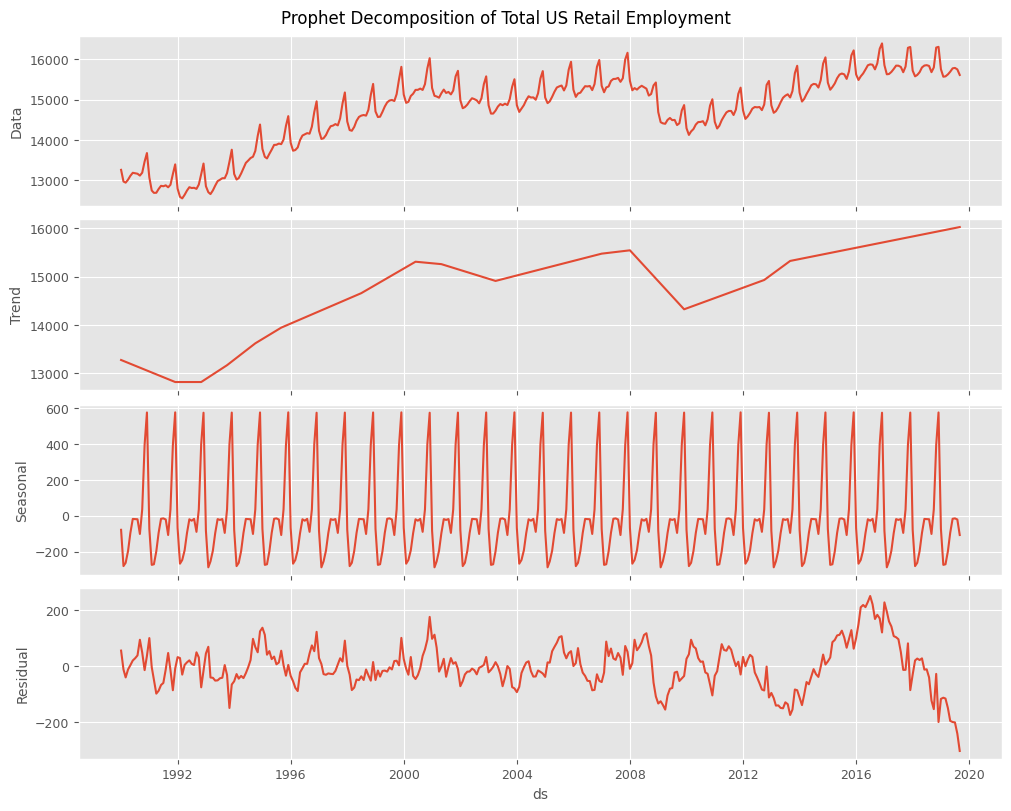

In [20]:
df_dcmp_prophet = pd.concat([fitted.trend, fitted.yearly, df_p.set_index('ds').y - fitted.yhat], axis=1)
df_dcmp_prophet.rename({0: 'resid'}, axis=1, inplace=True)
df_dcmp_prophet['t+s+r'] = df_dcmp_prophet.sum(axis=1)

fig, axes = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10, 8))
sns.lineplot(data=df_dcmp_prophet, x='ds', y='t+s+r', ax=axes[0])
sns.lineplot(data=df_dcmp_prophet, x='ds', y='trend', ax=axes[1])
sns.lineplot(data=df_dcmp_prophet, x='ds', y='yearly', ax=axes[2])
sns.lineplot(data=df_dcmp_prophet, x='ds', y='resid', ax=axes[3]) # can swap to scatter plot if you want
#sns.scatterplot(data=df_dcmp_prophet, x='ds', y='resid', ax=axes[3])
axes[0].set_ylabel('Data')
axes[1].set_ylabel('Trend')
axes[2].set_ylabel('Seasonal')
axes[3].set_ylabel('Residual')
fig.suptitle("Prophet Decomposition of Total US Retail Employment")
plt.show()

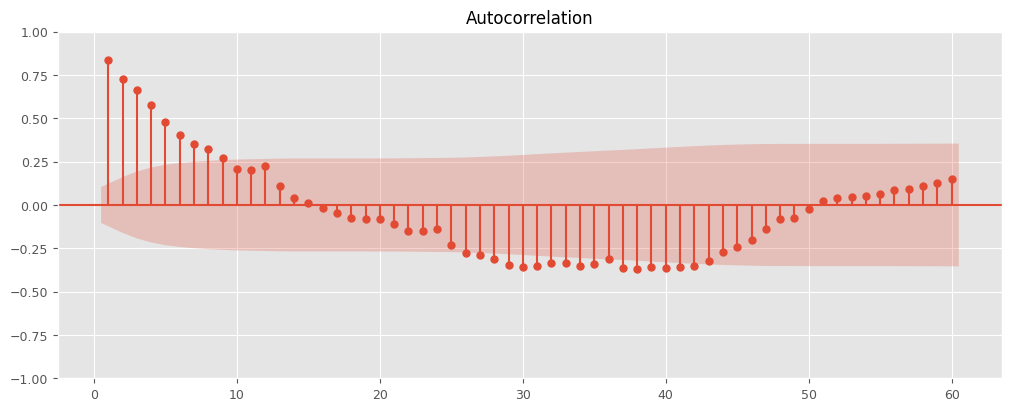

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(df_dcmp_prophet['resid'], zero=False, lags=60, ax=ax)
plt.show()

There is substantial remaining autocorrelation in the residuals.

### Final Notes on Prophet

- Prophet has the advantage of being "automated" and sometimes faster than other methods (does not scale well to very large datasets).
- Prediction intervals on the estimated decompositions are calculated automatically.
- Explicitly allows the forecaster to account for holiday effects.
- Out-of-the-box performance is usually not good. Needs a lot of tuning.